# 9. Auditoría de fuga de datos (sección 2.5)

*Autores: María Carolina Cantillo Orozco (200179105) y Juan Camilo Oñoro Araujo (200177329)*

La fuga ocurre cuando el modelo usa información que **no estaría disponible
en el momento de predecir**, lo que produce estimaciones optimistas (notas de
clase, sección 10.3). Se revisa:

1. Disponibilidad de cada variable al momento de la predicción.
2. Variables derivadas del objetivo, identificadores y proxies.
3. Desempeño **univariado** de cada variable (AUC one-vs-rest): valores
   cercanos a 1 son señal de alerta.
4. Entidades repetidas entre entrenamiento y prueba.

**Escenario de predicción:** se conoce la ficha catastral de una unidad de
vivienda (características físicas, régimen, uso) y su ubicación, pero **no**
su estrato, ni el de sus vecinos inmediatos.

In [1]:
# Preparación: librerías, módulos propios y datos. Solo se carga train (la auditoría
# decide qué variables entran al modelo, así que no puede mirar test) y el registro
# de decisiones de capítulos anteriores (variables con log, tamaño del buffer).
import sys
import warnings
from pathlib import Path

# Raíz del libro en el path, se ejecute desde notebooks/ o desde la raíz.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
# Se silencian avisos (p. ej. de convergencia en variables casi constantes), que
# se repetirían cientos de veces dentro de los folds sin aportar información.
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from joblib import Parallel, delayed
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

from src import config as C
from src import estadistica as E
from src import graficos as G
from src import modelo as M
from src import particion as P

G.estilo()  # estilo común de figuras
C.aviso_sintetico()  # avisa si se ejecuta con el CSV sintético de pruebas
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.max_colwidth", 90)  # para leer las justificaciones de la tabla 9.1
train = P.cargar_particion(solo="train")
# Decisiones registradas por el EDA (decisiones_eda.json): así el AUC univariado usa
# el mismo preprocesamiento y el mismo buffer que el modelo final.
dec = C.leer_decisiones()
# Variables numéricas sesgadas que reciben log1p (cap. 5); lista vacía si no existe.
num_log = dec.get("num_log", {}).get("valor", [])
# Buffer elegido con el correlograma (cap. 8.4); 0.5 km solo como respaldo si el
# capítulo 8 no se ha ejecutado.
buffer_km = dec.get("buffer_km", {}).get("valor", 0.5)

## 9.1 Disponibilidad, derivación del objetivo, identificadores y proxies

In [2]:
# Auditoría cualitativa, variable por variable: ¿estaría disponible al predecir el
# estrato de una vivienda nueva? ¿se deriva del objetivo? ¿es un identificador o
# un proxy de la ubicación fina? Cada fila deja escrita la decisión y su porqué.
auditoria = pd.DataFrame([
    ("numero_predial_nacional", "sí", "no", "IDENTIFICADOR; sus dígitos codifican sector, barrio y manzana, y el estrato se asigna por manzana → proxy casi perfecto de la ubicación fina", "EXCLUIR"),
    ("npn_edificio", "sí", "no", "IDENTIFICADOR de edificio: usarlo permitiría memorizar el estrato de cada edificio", "EXCLUIR (solo para agrupar)"),
    ("estrato (texto)", "no", "sí", "Es el objetivo en texto", "EXCLUIR"),
    ("centroide_fuente", "sí", "no", "Metadato de cómo se construyó el dato (pipeline), no una característica de la vivienda; redundante con condicion_predio", "EXCLUIR"),
    ("bloque / particion", "—", "no", "Artefactos de la partición", "EXCLUIR"),
    ("flag_imposible_*, flag_incoherente_*", "sí", "no", "Equivalentes al indicador de faltante que ya agrega el imputador", "EXCLUIR (redundantes)"),
    ("anio_construccion", "sí", "no", "Se usa transformada como antigüedad", "sustituida por antiguedad"),
    ("area_construida, habitaciones, baños, plantas, antigüedad, planta_ubicacion", "sí", "no", "Ficha catastral física, anterior a la asignación de estrato", "INCLUIR"),
    ("area_catastral_terreno", "sí", "no", "Ficha catastral del predio", "INCLUIR"),
    ("altura", "sí", "no", "Ficha catastral; casi constante (vale 3 en el 99.7 % de las filas, cap. 5) y sin asociación con el estrato (cap. 6)", "INCLUIR (aporta poco)"),
    ("tipo_vivienda, uso, condicion_predio", "sí", "no", "Ficha catastral. Revisar que ninguna categoría codifique el estrato (AUC univariado)", "INCLUIR / en observación"),
    ("destinacion_economica, tipo_planta", "sí", "no", "Ficha catastral; asociación casi nula con el estrato (cap. 6)", "según V de Cramér"),
    ("x_km, y_km, dist_centro_km", "sí", "no", "Ubicación conocida al predecir. Riesgo de fuga espacial controlado con bloques + buffer", "INCLUIR (en observación)"),
    ("rezago espacial del estrato (vecinos)", "NO", "sí (de vecinos)", "Requiere el estrato de los vecinos, que es lo que se quiere predecir; con Moran ≈ 0.9 volvería trivial el problema", "NO SE CONSTRUYE"),
], columns=["variable", "¿disponible al predecir?", "¿derivada del objetivo?", "justificación", "decisión"])
auditoria

,variable,¿disponible al predecir?,¿derivada del objetivo?,justificación,decisión
0,numero_predial_nacional,sí,no,"IDENTIFICADOR; sus dígitos codifican sector, barrio y manzana, y el estrato se asigna ...",EXCLUIR
1,npn_edificio,sí,no,IDENTIFICADOR de edificio: usarlo permitiría memorizar el estrato de cada edificio,EXCLUIR (solo para agrupar)
2,estrato (texto),no,sí,Es el objetivo en texto,EXCLUIR
3,centroide_fuente,sí,no,"Metadato de cómo se construyó el dato (pipeline), no una característica de la vivienda...",EXCLUIR
4,bloque / particion,—,no,Artefactos de la partición,EXCLUIR
5,"flag_imposible_*, flag_incoherente_*",sí,no,Equivalentes al indicador de faltante que ya agrega el imputador,EXCLUIR (redundantes)
6,anio_construccion,sí,no,Se usa transformada como antigüedad,sustituida por antiguedad
7,"area_construida, habitaciones, baños, plantas, antigüedad, planta_ubicacion",sí,no,"Ficha catastral física, anterior a la asignación de estrato",INCLUIR
8,area_catastral_terreno,sí,no,Ficha catastral del predio,INCLUIR
9,altura,sí,no,"Ficha catastral; casi constante (vale 3 en el 99.7 % de las filas, cap. 5) y sin asoci...",INCLUIR (aporta poco)


## 9.2 Desempeño univariado (AUC one-vs-rest macro)

Para cada variable por separado se ajusta una regresión logística con solo
esa variable (con el mismo preprocesamiento del modelo) y se mide el AUC
macro one-vs-rest con la **misma validación espacial por bloques + buffer**.
Referencia de lectura: ≥ 0.95 alerta de fuga/proxy; 0.85–0.95 revisar;
0.7–0.85 informativa.

**El AUC se calcula dentro de cada fold y luego se promedia.** Si se
calculara sobre las predicciones fuera-de-fold *agrupadas* de los 5 folds,
variables sin información podrían dar AUC < 0.5 (incluso una constante como
`tipo_planta`). Es un artefacto conocido: con una variable
sin información el modelo predice la proporción de clases de su fold de
entrenamiento, y en validación por bloques esa proporción es *menor*
justamente en el fold que tiene *más* casos de la clase (el total es fijo),
así que al agrupar folds las probabilidades quedan anticorrelacionadas con la
verdad. Promediar el AUC por fold compara solo predicciones de un mismo
modelo y elimina el artefacto (Forman y Scholz, 2010).

Para las espaciales se compara además con una validación **aleatoria**
(StratifiedKFold): la diferencia muestra cuánto "copia" la ubicación cuando
no se controla la vecindad.

In [3]:
# AUC univariado: una regresión logística con UNA sola variable por vez, evaluada
# con la misma validación espacial (bloques de 2 km + buffer) que el modelo. Un AUC
# cercano a 1 delataría una variable que "contiene" el estrato (fuga o proxy).
# Folds de train: folds_estratificados_por_grupo (bloques de 2 km, estratificado por
# estrato, semilla fija), excluyendo del entrenamiento de cada fold los puntos a
# menos de buffer_km de la validación.
folds = P.folds_espaciales_con_buffer(train, buffer_km, verbose=False)
y = train[C.OBJETIVO].to_numpy()
# Validación ALEATORIA de contraste (solo para las espaciales): mide cuánto "copia"
# la ubicación el estrato de los vecinos cuando no se controla la vecindad.
aleatorio = StratifiedKFold(n_splits=C.N_FOLDS, shuffle=True, random_state=C.SEED)
# Candidatas: todas las numéricas, espaciales y categóricas presentes, más el
# metadato centroide_fuente, para documentar por qué se excluye.
candidatas = [c for c in C.NUMERICAS + C.ESPACIALES if c in train] + \
             [c for c in C.CATEGORICAS if c in train] + ["centroide_fuente"]


def _auc_fold(pipe, X, tr, va):
    """AUC OvR macro en UN fold, solo con las clases presentes en validación."""
    # clone: un pipeline nuevo sin ajustar por fold; el preprocesador (winsorizado,
    # imputación, escalado, one-hot) se ajusta SOLO con el train del fold.
    m = clone(pipe).fit(X.iloc[tr], y[tr])
    proba = m.predict_proba(X.iloc[va])
    aucs = []
    # One-vs-rest: un AUC binario por clase (clase k contra las demás) y luego media
    # simple (macro), de modo que los estratos minoritarios pesan lo mismo.
    for k, clase in enumerate(m.classes_):
        pos = y[va] == clase
        # Un bloque de validación puede no tener alguna clase (p. ej. estrato 6 en el
        # sur): el AUC no está definido sin positivos o sin negativos, así que se omite.
        if 0 < pos.sum() < len(pos):
            aucs.append(roc_auc_score(pos, proba[:, k]))
    return np.mean(aucs) if aucs else np.nan


def auc_univariado(var, cv):
    """Media (y desviación) del AUC por fold: no se agrupan predicciones de folds distintos."""
    # Por qué NO se agrupan las predicciones fuera-de-fold de los 5 folds: cada fold
    # tiene su propio modelo. Con una variable sin información, el modelo predice la
    # proporción de clases de su train; en validación por bloques, el fold con MÁS
    # casos de una clase deja MENOS de esa clase en su train (el total es fijo), así
    # que predice una probabilidad más baja justo donde la clase abunda. Al juntar
    # los folds, las probabilidades quedan anticorrelacionadas con la verdad y el
    # AUC cae por debajo de 0.5 de forma espuria. Calcular el AUC dentro de cada fold
    # (un solo modelo) y promediar evita el sesgo (Forman y Scholz, 2010).
    es_cat = var in C.CATEGORICAS or var == "centroide_fuente"
    # Mismo preprocesamiento que el modelo final: log1p si la variable es sesgada,
    # escalado lineal si es numérica no sesgada, one-hot si es categórica.
    prep = M.construir_preprocesador(num_log=[var] if var in num_log else [],
                                     num_lineal=[] if (es_cat or var in num_log) else [var],
                                     categoricas=[var] if es_cat else [])
    # Pipeline preprocesador + logística: todo se ajusta dentro del fold (sin fuga).
    pipe = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=300))])
    X = train[[var]]
    # Acepta un objeto de sklearn con .split (validación aleatoria) o la lista de
    # (idx_train, idx_val) ya construida (validación espacial con buffer).
    divisiones = list(cv.split(X, y)) if hasattr(cv, "split") else cv
    # Los folds son independientes entre sí: se ajustan en paralelo en todos los núcleos.
    aucs = Parallel(n_jobs=-1)(delayed(_auc_fold)(pipe, X, tr, va) for tr, va in divisiones)
    # Media y desviación entre folds (nanmean: ignora folds sin AUC definido).
    return float(np.nanmean(aucs)), float(np.nanstd(aucs))


filas = []
for v in candidatas:
    media, sd = auc_univariado(v, folds)
    fila = {"variable": v, "AUC espacial (bloques+buffer)": media, "desv. entre folds": sd}
    # Solo para las espaciales se agrega el AUC con validación aleatoria: la brecha
    # aleatorio - espacial es la "ventaja" que da conocer la vecindad.
    if v in C.ESPACIALES:
        fila["AUC aleatorio (StratifiedKFold)"] = auc_univariado(v, aleatorio)[0]
    filas.append(fila)
auc_uni = pd.DataFrame(filas).set_index("variable").sort_values("AUC espacial (bloques+buffer)", ascending=False)
# Lectura por umbrales: >= 0.95 alerta de fuga, 0.85-0.95 revisar, 0.7-0.85 informativa.
auc_uni["lectura"] = auc_uni["AUC espacial (bloques+buffer)"].map(E.interpretar_auc_univariado)
auc_uni

,AUC espacial (bloques+buffer),desv. entre folds,AUC aleatorio (StratifiedKFold),lectura
variable,,,,
y_km,0.764,0.058,0.778,informativo
total_banios,0.688,0.007,NaN,débil
area_construida,0.633,0.036,NaN,débil
dist_centro_km,0.630,0.042,0.713,débil
condicion_predio,0.629,0.049,NaN,débil
centroide_fuente,0.615,0.026,NaN,débil
uso,0.606,0.048,NaN,débil
planta_ubicacion,0.599,0.043,NaN,casi nulo
x_km,0.573,0.074,0.670,casi nulo


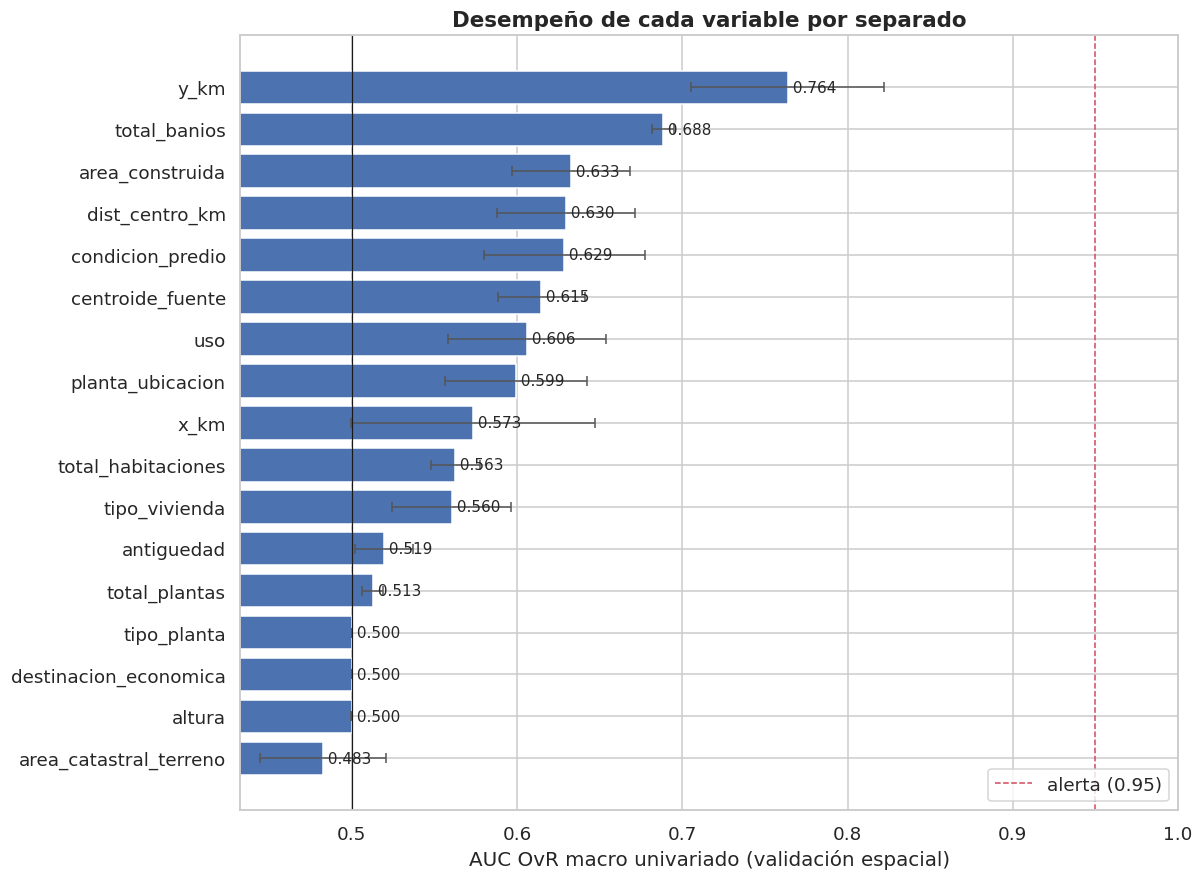

In [4]:
# Barras horizontales del AUC univariado espacial de cada variable, con la
# desviación entre folds como barra de error. La línea negra (0.5) es el azar y la
# roja discontinua (0.95) el umbral de alerta de fuga.
# Alto de la figura proporcional al número de variables, para que no se encimen.
fig, ax = plt.subplots(figsize=(11, 0.45 * len(auc_uni) + 1.5))
# Orden invertido: barh dibuja de abajo hacia arriba y así la mayor queda arriba.
vals = auc_uni["AUC espacial (bloques+buffer)"][::-1]
# Rojo: alerta (>= 0.95); ámbar: revisar (>= 0.85); azul: sin sospecha de fuga.
colores = ["#d1495b" if v >= 0.95 else ("#edae49" if v >= 0.85 else "#4c72b0") for v in vals]
ax.barh(vals.index, vals.values, color=colores,
        xerr=auc_uni["desv. entre folds"][::-1].values, error_kw={"lw": 1, "capsize": 3, "ecolor": "#555555"})
# Valor numérico al final de cada barra.
for i, v in enumerate(vals.values):
    ax.text(v, i, f" {v:.3f}", va="center", fontsize=10)
ax.axvline(0.5, color="k", lw=0.8)
ax.axvline(0.95, color="#d1495b", ls="--", lw=1, label="alerta (0.95)")
# El eje empieza un poco por debajo del mínimo para que se vean los AUC < 0.5.
ax.set_xlim(min(0.45, float(vals.min()) - 0.05), 1.0)
ax.set_xlabel("AUC OvR macro univariado (validación espacial)")
ax.set_title("Desempeño de cada variable por separado")
ax.legend(loc="lower right")
G.guardar(fig, "09_auc_univariado")
plt.show()

```{admonition} Interpretación
:class: note
- **Ninguna variable se acerca a la alerta de 0.95**; la más alta llega a
  0.76. No hay una predictora que "contenga" el estrato, y las categóricas
  (`uso`, `condicion_predio`, `tipo_vivienda`) no tienen una categoría
  exclusiva de un estrato (cap. 6: V ≤ 0.33).
- La variable individual más informativa en zonas no vistas es **`y_km`**
  (AUC = 0.76), seguida de **baños** (0.69), distancia al centro, área
  construida y `condicion_predio` (≈ 0.63 cada una). Es coherente con el EDA
  (cap. 6: η² = 0.50 para y_km y 0.31 para baños).
- **Aleatoria frente a espacial:** en `y_km` la brecha es pequeña (0.78
  frente a 0.76), porque el gradiente norte-sur es de gran escala y se
  transfiere entre zonas. En cambio, `x_km` (0.67 frente a 0.57) y la
  distancia al centro (0.71 frente a 0.63) pierden mucho más: por sí solas
  mezclan el norte (estratos altos) con el sur (bajos) a la misma longitud o
  distancia, y solo discriminan cuando hay vecinos de la misma zona en
  entrenamiento. Esa diferencia es la "ventaja" que la validación por
  bloques elimina.
- **`area_catastral_terreno` queda por debajo de 0.5** (0.48 ± 0.04): por
  sí sola, lo que el modelo aprende de ella en unas zonas se invierte en
  otras. Es coherente con su relación no monótona con el estrato (cap. 6:
  medianas de 66, 91 y 72 m² en los estratos 1–3 frente a 38, 46 y 52 m² en
  los 4–6) y con la heterogeneidad espacial del cap. 8.5.
- Las variables constantes o casi constantes (`tipo_planta`,
  `destinacion_economica`, `altura`) dan **exactamente 0.500** (desviación
  0 entre folds), como debe ser con una variable sin información: el
  cálculo por fold no tiene el sesgo descrito arriba. Las dos primeras son
  degeneradas (cap. 5) y se excluyen en la lista final (9.4); `altura`, casi
  constante (cap. 5: vale 3 en más del 99 % de las filas), se mantiene,
  pero no aporta información.
- `centroide_fuente` (0.61) se excluye aunque no sea despreciable: es un
  metadato del pipeline de descarga (propagado = apartamento), redundante
  con `condicion_predio`.
```

## 9.3 Entidades repetidas entre entrenamiento y prueba

Esta verificación solo usa **identificadores** del conjunto de prueba (no
sus etiquetas ni sus distribuciones).

In [5]:
# Entidades compartidas entre train y test: si un mismo edificio, predio o
# coordenada aparece en ambos lados, el modelo podría "reconocerlo" en vez de
# generalizar (fuga por grupo). Solo se usan IDENTIFICADORES de test, nunca su
# estrato ni sus distribuciones, así que test sigue sin influir en decisiones.
todo = P.cargar_particion()  # train + test, con la columna "particion"
ids = {}
# Intersección de conjuntos de identificadores de cada lado (se ignoran nulos).
for col, nombre in [("npn_edificio", "edificios"), ("numero_predial_nacional", "predios"), ("bloque", "bloques")]:
    a = set(todo.loc[todo.particion == "train", col].dropna())
    b = set(todo.loc[todo.particion == "test", col].dropna())
    ids[f"{nombre} compartidos"] = len(a & b)
# Coordenadas redondeadas a 6 decimales (~0.1 m) y convertidas a texto, para comparar
# centroides como claves exactas sin problemas de coma flotante.
coord = todo["centroide_lat"].round(6).astype(str) + "_" + todo["centroide_lon"].round(6).astype(str)
ids["coordenadas idénticas compartidas"] = len(set(coord[todo.particion == "train"]) & set(coord[todo.particion == "test"]))
# Unidades de train demasiado cercanas a test: mascara_buffer devuelve True para
# las que están a >= buffer_km de todo punto de test (búsqueda con KDTree en km).
from src.particion import mascara_buffer
xy_tr = todo.loc[todo.particion == "train", ["x_km", "y_km"]].to_numpy()
xy_te = todo.loc[todo.particion == "test", ["x_km", "y_km"]].to_numpy()
# "~" invierte la máscara: se cuentan las que caen DENTRO del buffer, que el modelo
# final excluirá del entrenamiento para que test evalúe zonas realmente no vistas.
ids[f"unidades de train a < {buffer_km} km de test (se excluirán)"] = int((~mascara_buffer(xy_tr, xy_te, buffer_km)).sum())
pd.Series(ids, name="conteo").to_frame()

,conteo
edificios compartidos,0
predios compartidos,0
bloques compartidos,1
coordenadas idénticas compartidas,0
unidades de train a < 1.0 km de test (se excluirán),80631


```{admonition} Interpretación
:class: note
- **Cero edificios, cero predios y cero coordenadas idénticas** compartidos
  entre train y test: ningún apartamento tiene un "gemelo" del mismo edificio
  al otro lado de la partición. El único bloque que aparece en ambos es el
  del edificio que se movió completo a test (cap. 2).
- **80 631 unidades de train** (el 37 %) están a menos de 1 km de algún
  punto de test. En el modelo final (cap. 10) se excluyen del
  entrenamiento: es el costo de que el test evalúe de verdad zonas no
  vistas. Train pasa de 218 870 a 138 239 filas.
```

## 9.4 Lista final de variables

In [6]:
# Lista final de variables del modelo: se parte de las listas preliminares que ya
# pasaron los filtros de VIF y V de Cramér (cap. 6) y se quitan las que activaron la
# alerta de fuga (AUC univariado >= 0.95). Se registra en decisiones_eda.json, que
# es lo que lee el capítulo del modelo base.
# Si el cap. 6 no registró listas preliminares, se usan las de config.py.
nums_pre = dec.get("numericas_preliminares", {}).get("valor", C.NUMERICAS)
cats_pre = dec.get("categoricas_preliminares", {}).get("valor", C.CATEGORICAS)
alerta = auc_uni.index[auc_uni["AUC espacial (bloques+buffer)"] >= 0.95].tolist()
nums_final = [c for c in nums_pre if c not in alerta]
# centroide_fuente se excluye siempre: es un metadato del pipeline, no una
# característica de la vivienda (tabla 9.1).
cats_final = [c for c in cats_pre if c not in alerta and c != "centroide_fuente"]
esp_final = [c for c in C.ESPACIALES if c not in alerta]
# Excluidas = todas las candidatas de config.py menos las finales (por VIF,
# asociación nula o alerta de fuga), para dejar constancia explícita.
excluidas = sorted(set(C.NUMERICAS + C.CATEGORICAS + C.ESPACIALES) - set(nums_final + cats_final + esp_final))
print("Numéricas:", nums_final)
print("Categóricas:", cats_final)
print("Espaciales:", esp_final)
print("Excluidas (VIF, asociación nula o alerta de fuga):", excluidas)
print("Identificadores/metadatos excluidos:", C.IDENTIFICADORES + C.METADATOS_PIPELINE)
C.guardar_decision("variables_modelo", {"numericas": nums_final, "categoricas": cats_final, "espaciales": esp_final},
                   "Tras VIF (cap. 6), V de Cramér (cap. 6) y auditoría de fuga (cap. 9): sin identificadores, "
                   "metadatos ni variables con AUC univariado ≥ 0.95.")
C.guardar_decision("variables_excluidas", excluidas + C.IDENTIFICADORES + ["centroide_fuente"],
                   "Ver tablas 9.1 y 9.2.")

Numéricas: ['area_construida', 'area_catastral_terreno', 'total_habitaciones', 'total_banios', 'total_plantas', 'antiguedad', 'planta_ubicacion', 'altura']
Categóricas: ['tipo_vivienda', 'uso', 'condicion_predio']
Espaciales: ['x_km', 'y_km', 'dist_centro_km']
Excluidas (VIF, asociación nula o alerta de fuga): ['destinacion_economica', 'tipo_planta']
Identificadores/metadatos excluidos: ['numero_predial_nacional', 'npn_edificio', 'id_fila', 'centroide_fuente', 'estrato', 'bloque', 'particion']
[decisión registrada] variables_modelo = {'numericas': ['area_construida', 'area_catastral_terreno', 'total_habitaciones', 'total_banios', 'total_plantas', 'antiguedad', 'planta_ubicacion', 'altura'], 'categoricas': ['tipo_vivienda', 'uso', 'condicion_predio'], 'espaciales': ['x_km', 'y_km', 'dist_centro_km']}
   motivo: Tras VIF (cap. 6), V de Cramér (cap. 6) y auditoría de fuga (cap. 9): sin identificadores, metadatos ni variables con AUC univariado ≥ 0.95.
[decisión registrada] variables_exclu